# 🧠 Building Blocks of a GenAI Chatbot — Interactive Codelab

**Companion notebook for Class 1 | Conversational AI Applications | IIT Hyderabad**

This notebook provides hands-on code for every building block covered in the lecture:

| # | Building Block | What You’ll Code |
|---|---|---|
| 01 | **Tokenisation** | BPE, WordPiece & SentencePiece side-by-side |
| 02 | **Embeddings** | Vector arithmetic, similarity & visualisation |
| 03 | **Model Inference** | Transformer forward pass & decoding strategies |
| 04 | **Dialogue State** | Building a slot-filling state tracker |
| 05 | **Response Generation** | Prompt engineering, RAG pipeline & tool use |
| 06 | **Memory** | Buffer, summary & vector memory systems |

---

## Setup — Install Dependencies

Run this cell once to install all required packages.

In [ ]:
!pip3 install -q tiktoken transformers torch sentencepiece sentence-transformers numpy scikit-learn matplotlib

---

# 01 — Tokenisation

> *"How ChatGPT breaks ‘unbelievable’ into [\"un\", \"believ\", \"able\"] — the first step in understanding text"*

We’ll compare three tokenisation algorithms:
- **BPE** (Byte-Pair Encoding) — used by GPT-4, Claude
- **WordPiece** — used by BERT
- **SentencePiece** — used by Gemini, T5

### 1.1 — BPE with `tiktoken` (GPT-4’s Tokeniser)

In [6]:
import tiktoken

# Load GPT-4's tokeniser (cl100k_base encoding)
enc = tiktoken.encoding_for_model("gpt-4")

text = "Sai Sanjana earns 200000000 Indian Rupees"
token_ids = enc.encode(text)
tokens = [enc.decode([t]) for t in token_ids]

print(f"Input text:  '{text}'")
print(f"Token IDs:   {token_ids}")
print(f"Tokens:      {tokens}")
print(f"Token count: {len(token_ids)}")

Input text:  'Sai Sanjana earns 200000000 Indian Rupees'
Token IDs:   [50, 2192, 5960, 73, 3444, 64859, 220, 1049, 931, 931, 7904, 29014, 82400]
Tokens:      ['S', 'ai', ' San', 'j', 'ana', ' earns', ' ', '200', '000', '000', ' Indian', ' Ru', 'pees']
Token count: 13


In [3]:
# Visualise how different texts get tokenised
examples = [
    "Hello, world!",
    "Tokenisation is fascinating",
    "The quick brown fox jumps over the lazy dog",
    "भारत एक विशाल देश है",   # Hindi
    "東京は日本の首都です",        # Japanese
    "def fibonacci(n): return n if n < 2 else fibonacci(n-1) + fibonacci(n-2)",  # Code
]

print(f"{'Text':<55} {'Tokens':>6}  Token Breakdown")
print("-" * 120)
for ex in examples:
    ids = enc.encode(ex)
    toks = [enc.decode([t]) for t in ids]
    print(f"{ex:<55} {len(ids):>6}  {toks}")

Text                                                    Tokens  Token Breakdown
------------------------------------------------------------------------------------------------------------------------
Hello, world!                                                4  ['Hello', ',', ' world', '!']
Tokenisation is fascinating                                  4  ['Token', 'isation', ' is', ' fascinating']
The quick brown fox jumps over the lazy dog                  9  ['The', ' quick', ' brown', ' fox', ' jumps', ' over', ' the', ' lazy', ' dog']
भारत एक विशाल देश है                                        21  ['�', '�', 'ा�', '�', 'त', ' �', '�', 'क', ' �', '�', 'ि�', '�', 'ा�', '�', ' �', '�', 'े�', '�', ' ह', '�', '�']
東京は日本の首都です                                                  10  ['�', '�', '京', 'は', '日', '本', 'の', '首', '都', 'です']
def fibonacci(n): return n if n < 2 else fibonacci(n-1) + fibonacci(n-2)     23  ['def', ' fibonacci', '(n', '):', ' return', ' n', ' if', ' n', ' <', ' ', '2'

**🔍 Observation:** Notice how non-English text requires many more tokens. This is because BPE merges are trained primarily on English corpora. Code tokens tend to be short because variable names are split into subwords.

> **✨ Try it yourself:** Add your own sentences above — try emojis, URLs, or code snippets!

### 1.2 — BPE from Scratch

Let’s implement the BPE merge algorithm step by step, exactly as shown in the lecture slide.

In [4]:
from collections import Counter

def get_pair_counts(tokens_list):
    """Count adjacent pairs across all words."""
    pairs = Counter()
    for word_tokens in tokens_list:
        for i in range(len(word_tokens) - 1):
            pairs[(word_tokens[i], word_tokens[i + 1])] += 1
    return pairs

def merge_pair(tokens_list, pair, merged):
    """Merge all occurrences of a pair into a single token."""
    new_tokens_list = []
    for word_tokens in tokens_list:
        new_word = []
        i = 0
        while i < len(word_tokens):
            if i < len(word_tokens) - 1 and (word_tokens[i], word_tokens[i + 1]) == pair:
                new_word.append(merged)
                i += 2
            else:
                new_word.append(word_tokens[i])
                i += 1
        new_tokens_list.append(new_word)
    return new_tokens_list

# The example from the lecture slide
text = "aaabdaaabac"
tokens_list = [list(text)]  # Start with characters

print(f"Input: '{text}'")
print(f"Step 0 (chars): {tokens_list[0]}  →  {len(tokens_list[0])} tokens\n")

num_merges = 3
for step in range(1, num_merges + 1):
    pairs = get_pair_counts(tokens_list)
    if not pairs:
        break
    best_pair = pairs.most_common(1)[0]
    merged_token = best_pair[0][0] + best_pair[0][1]
    tokens_list = merge_pair(tokens_list, best_pair[0], merged_token)
    print(f"Step {step}: Most frequent pair = {best_pair[0]} (count={best_pair[1]})")
    print(f"         Merged → '{merged_token}'")
    print(f"         Result: {tokens_list[0]}  →  {len(tokens_list[0])} tokens\n")

ratio = len(text) / len(tokens_list[0])
print(f"Compression: {len(text)} chars → {len(tokens_list[0])} tokens = {ratio:.1f}x")

Input: 'aaabdaaabac'
Step 0 (chars): ['a', 'a', 'a', 'b', 'd', 'a', 'a', 'a', 'b', 'a', 'c']  →  11 tokens

Step 1: Most frequent pair = ('a', 'a') (count=4)
         Merged → 'aa'
         Result: ['aa', 'a', 'b', 'd', 'aa', 'a', 'b', 'a', 'c']  →  9 tokens

Step 2: Most frequent pair = ('aa', 'a') (count=2)
         Merged → 'aaa'
         Result: ['aaa', 'b', 'd', 'aaa', 'b', 'a', 'c']  →  7 tokens

Step 3: Most frequent pair = ('aaa', 'b') (count=2)
         Merged → 'aaab'
         Result: ['aaab', 'd', 'aaab', 'a', 'c']  →  5 tokens

Compression: 11 chars → 5 tokens = 2.2x


### 1.3 — WordPiece with HuggingFace (BERT’s Tokeniser)

In [9]:
from transformers import AutoTokenizer

# Load BERT's WordPiece tokeniser
wp_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

text = "ChatGPT is unbelievably ##fast"
tokens = wp_tokenizer.tokenize(text)
token_ids = wp_tokenizer.encode(text, add_special_tokens=False)

print(f"Input:     '{text}'")
print(f"Tokens:    {tokens}")
print(f"Token IDs: {token_ids}")
print(f"\nNotice the '##' prefix on continuation tokens!")
print(f"'unbelievably' → {wp_tokenizer.tokenize('unbelievably')}")
print(f"'playing'      → {wp_tokenizer.tokenize('playing')}")

Input:     'ChatGPT is unbelievably ##fast'
Tokens:    ['chat', '##gp', '##t', 'is', 'un', '##bel', '##ie', '##va', '##bly', '#', '#', 'fast']
Token IDs: [11834, 21600, 2102, 2003, 4895, 8671, 2666, 3567, 6321, 1001, 1001, 3435]

Notice the '##' prefix on continuation tokens!
'unbelievably' → ['un', '##bel', '##ie', '##va', '##bly']
'playing'      → ['playing']


### 1.4 — SentencePiece (Gemini / T5 Style)

In [10]:
# Load T5's SentencePiece tokeniser (same family as Gemini)
sp_tokenizer = AutoTokenizer.from_pretrained("t5-base")

text = "ChatGPT is unbelievably ##fast"
tokens = sp_tokenizer.tokenize(text)
token_ids = sp_tokenizer.encode(text, add_special_tokens=False)

print(f"Input:     '{text}'")
print(f"Tokens:    {tokens}")
print(f"Token IDs: {token_ids}")
print(f"\nNotice the '▁' (underscore) prefix for word boundaries!")
print(f"'Hello world'  → {sp_tokenizer.tokenize('Hello world')}")
print(f"'Helloworld'   → {sp_tokenizer.tokenize('Helloworld')}")

Input:     'ChatGPT is unbelievably ##fast'
Tokens:    ['▁Chat', 'GP', 'T', '▁is', '▁unbe', 'lie', 'v', 'ably', '▁', '##', 'fast']
Token IDs: [9802, 8049, 382, 19, 12658, 1896, 208, 3834, 3, 30345, 11584]

Notice the '▁' (underscore) prefix for word boundaries!
'Hello world'  → ['▁Hello', '▁world']
'Helloworld'   → ['▁Hello', 'world']


### 1.5 — Side-by-Side Comparison

In [11]:
test_sentences = [
    "ChatGPT is unbelievably fast",
    "The transformer architecture revolutionized NLP",
    "I can't believe it's not butter!",
    "भारत एक विशाल देश है",
    "def hello(): print('world')",
]

print(f"{'Sentence':<50} {'BPE(GPT4)':>10} {'WordPiece':>10} {'SentPiece':>10}")
print("=" * 85)
for sent in test_sentences:
    bpe_count = len(enc.encode(sent))
    wp_count = len(wp_tokenizer.tokenize(sent))
    sp_count = len(sp_tokenizer.tokenize(sent))
    print(f"{sent:<50} {bpe_count:>10} {wp_count:>10} {sp_count:>10}")

Sentence                                            BPE(GPT4)  WordPiece  SentPiece
ChatGPT is unbelievably fast                                7         10          9
The transformer architecture revolutionized NLP             7          8          7
I can't believe it's not butter!                            9         11         11
भारत एक विशाल देश है                                       21         14         10
def hello(): print('world')                                 7         11         11


**💡 Key Takeaway:** Different tokenisers produce different token counts for the same input. This affects model cost (more tokens = more expensive) and multilingual performance.

---

# 02 — Embeddings

> *"Converting words into vectors so that king − man + woman = queen"*

### 2.1 — Loading Pre-trained Word Embeddings

In [13]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load a sentence embedding model (384-dimensional)
model = SentenceTransformer('all-MiniLM-L6-v2')

# Embed some words
words = ["king", "queen", "man", "woman", "prince", "princess", "table", "chair", "computer"]
embeddings = model.encode(words)
embeddings.shape

print(f"Model dimension: {embeddings.shape[1]}")
print(f"\nEmbedding for 'king' (first 10 dims):")
print(f"  {embeddings[0][:10].round(4)}")
print(f"\nEmbedding for 'table' (first 10 dims):")
print(f"  {embeddings[6][:10].round(4)}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9219.63it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model dimension: 384

Embedding for 'king' (first 10 dims):
  [-0.0596  0.0505 -0.0695  0.0797 -0.0467  0.001   0.079  -0.0127  0.0584
 -0.0314]

Embedding for 'table' (first 10 dims):
  [ 0.0314  0.0013 -0.0916  0.0166 -0.0616  0.0303  0.0982  0.0313  0.0085
  0.0283]


### 2.2 — Cosine Similarity: Measuring Meaning

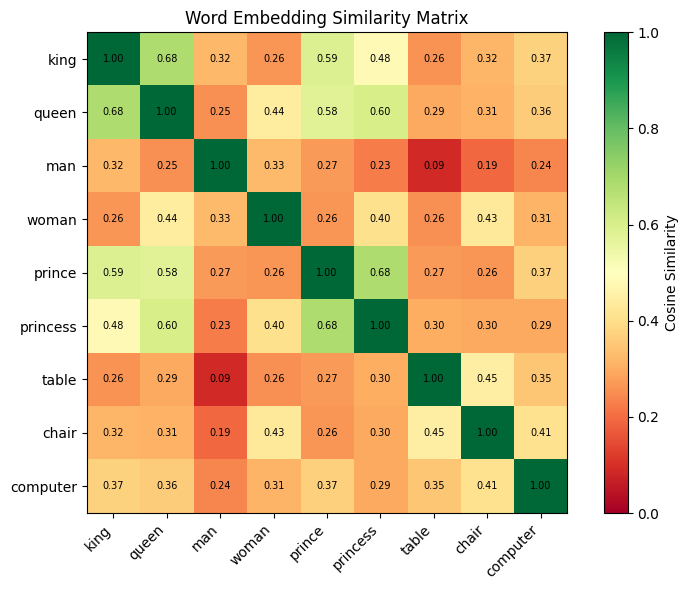

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute full similarity matrix
sim_matrix = cosine_similarity(embeddings)

# Display as a heatmap
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(words)))
ax.set_yticks(range(len(words)))
ax.set_xticklabels(words, rotation=45, ha='right')
ax.set_yticklabels(words)

# Add values in cells
for i in range(len(words)):
    for j in range(len(words)):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}", ha='center', va='center', fontsize=7)

plt.colorbar(im, label='Cosine Similarity')
plt.title('Word Embedding Similarity Matrix')
plt.tight_layout()
plt.show()

### 2.3 — The Famous Analogy: king − man + woman ≈ queen

In [15]:
def analogy(model, a, b, c, candidates):
    """
    Solve: a - b + c = ?
    Example: king - man + woman = queen
    """
    vecs = model.encode([a, b, c] + candidates)
    target = vecs[0] - vecs[1] + vecs[2]  # a - b + c

    # Find closest candidate
    candidate_vecs = vecs[3:]
    sims = cosine_similarity([target], candidate_vecs)[0]

    print(f"Analogy: {a} - {b} + {c} = ?\n")
    ranked = sorted(zip(candidates, sims), key=lambda x: -x[1])
    for word, sim in ranked:
        bar = '█' * int(sim * 30)
        marker = " ← BEST" if word == ranked[0][0] else ""
        print(f"  {word:<15} {sim:.4f}  {bar}{marker}")

# Classic analogy
analogy(model, "king", "man", "woman",
        ["queen", "princess", "prince", "table", "chair"])

print("\n" + "="*60 + "\n")

# Geographic analogy
analogy(model, "Paris", "France", "Japan",
        ["Tokyo", "Osaka", "Berlin", "London", "Sushi"])

Analogy: king - man + woman = ?

  queen           0.5795  █████████████████ ← BEST
  princess        0.4418  █████████████
  prince          0.3882  ███████████
  chair           0.3696  ███████████
  table           0.2875  ████████


Analogy: Paris - France + Japan = ?

  Tokyo           0.8552  █████████████████████████ ← BEST
  Osaka           0.7231  █████████████████████
  Berlin          0.4793  ██████████████
  London          0.4482  █████████████
  Sushi           0.3550  ██████████


### 2.4 — Sentence Embeddings & Semantic Search

In [16]:
# A mini document collection (knowledge base)
documents = [
    "Python is a high-level programming language known for its readability.",
    "Machine learning enables systems to learn from data without explicit programming.",
    "The Eiffel Tower is a wrought-iron lattice tower in Paris, France.",
    "Quantum computing uses qubits that can be in superposition states.",
    "Neural networks are inspired by biological neurons in the brain.",
    "The Great Wall of China stretches over 13,000 miles.",
    "Deep learning is a subset of machine learning using multi-layer neural networks.",
    "Transformers revolutionised NLP with the self-attention mechanism.",
]

doc_embeddings = model.encode(documents)

def semantic_search(query, top_k=3):
    """Find the most relevant documents for a query."""
    query_vec = model.encode([query])
    sims = cosine_similarity(query_vec, doc_embeddings)[0]
    ranked = sorted(enumerate(sims), key=lambda x: -x[1])[:top_k]

    print(f"Query: \"{query}\"\n")
    for rank, (idx, sim) in enumerate(ranked, 1):
        print(f"  {rank}. [{sim:.4f}] {documents[idx]}")
    print()

semantic_search("How do AI models learn?")
semantic_search("Tell me about famous landmarks")
semantic_search("What programming language is easy to read?")

Query: "How do AI models learn?"

  1. [0.4475] Machine learning enables systems to learn from data without explicit programming.
  2. [0.3769] Neural networks are inspired by biological neurons in the brain.
  3. [0.3722] Deep learning is a subset of machine learning using multi-layer neural networks.

Query: "Tell me about famous landmarks"

  1. [0.2550] The Great Wall of China stretches over 13,000 miles.
  2. [0.1710] The Eiffel Tower is a wrought-iron lattice tower in Paris, France.
  3. [0.0814] Deep learning is a subset of machine learning using multi-layer neural networks.

Query: "What programming language is easy to read?"

  1. [0.6331] Python is a high-level programming language known for its readability.
  2. [0.2633] Machine learning enables systems to learn from data without explicit programming.
  3. [0.2598] Transformers revolutionised NLP with the self-attention mechanism.



### 2.5 — Visualising Embeddings in 2D

/Users/nshah/IIT_Hyd_Undergrad_Basics/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/nshah/IIT_Hyd_Undergrad_Basics/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/nshah/IIT_Hyd_Undergrad_Basics/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/nshah/IIT_Hyd_Undergrad_Basics/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/nshah/IIT_Hyd_Undergrad_Basics/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/nshah/IIT_Hyd_Undergrad_Basics/.venv/lib/python3.10/site-packages/sklearn/utils/extmath

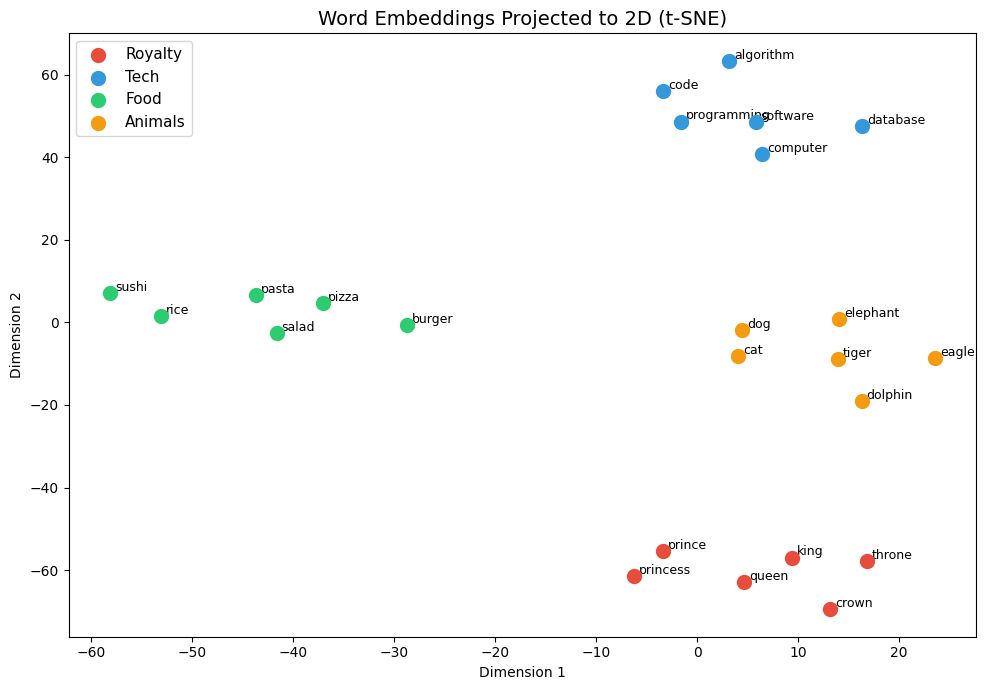

In [17]:
from sklearn.manifold import TSNE

# Embed a set of related and unrelated words
word_groups = {
    'Royalty':   ['king', 'queen', 'prince', 'princess', 'throne', 'crown'],
    'Tech':      ['computer', 'software', 'algorithm', 'database', 'programming', 'code'],
    'Food':      ['pizza', 'burger', 'sushi', 'pasta', 'salad', 'rice'],
    'Animals':   ['dog', 'cat', 'elephant', 'tiger', 'dolphin', 'eagle'],
}

all_words = []
all_labels = []
for group, words_list in word_groups.items():
    all_words.extend(words_list)
    all_labels.extend([group] * len(words_list))

all_embeddings = model.encode(all_words)

# Reduce to 2D with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
coords = tsne.fit_transform(all_embeddings)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
colors = {'Royalty': '#e74c3c', 'Tech': '#3498db', 'Food': '#2ecc71', 'Animals': '#f39c12'}

for i, (word, label) in enumerate(zip(all_words, all_labels)):
    ax.scatter(coords[i, 0], coords[i, 1], c=colors[label], s=100, zorder=5)
    ax.annotate(word, (coords[i, 0] + 0.5, coords[i, 1] + 0.5), fontsize=9)

# Legend
for label, color in colors.items():
    ax.scatter([], [], c=color, s=100, label=label)
ax.legend(fontsize=11)
ax.set_title('Word Embeddings Projected to 2D (t-SNE)', fontsize=14)
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
plt.tight_layout()
plt.show()

**💡 Key Takeaway:** Words from the same domain cluster together in embedding space. This is the foundation of how language models "understand" meaning.

---

# 03 — Model Inference

> *"The forward pass: how a trained transformer turns tokens into the next word prediction"*

### 3.1 — Transformer Forward Pass (with GPT-2)

In [18]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch
import torch.nn.functional as F

# Load GPT-2 (small, 124M params — same architecture family as GPT-4)
gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt2_model = GPT2LMHeadModel.from_pretrained("gpt2", attn_implementation="eager")
gpt2_model.eval()

prompt = "The capital of France is"
input_ids = gpt2_tokenizer.encode(prompt, return_tensors="pt")

# Forward pass — get raw logits
with torch.no_grad():
    outputs = gpt2_model(input_ids)
    logits = outputs.logits  # shape: [batch, seq_len, vocab_size]

# The last token's logits give the prediction for the NEXT token
next_token_logits = logits[0, -1, :]  # shape: [vocab_size]

print(f"Prompt: '{prompt}'")
print(f"Logits shape: {logits.shape}  (batch=1, seq_len={input_ids.shape[1]}, vocab={next_token_logits.shape[0]})")
print(f"\nTop 10 predicted next tokens:")

probs = F.softmax(next_token_logits, dim=0)
top_probs, top_indices = torch.topk(probs, 10)

for prob, idx in zip(top_probs, top_indices):
    token = gpt2_tokenizer.decode([idx])
    bar = '█' * int(prob * 100)
    print(f"  '{token:<12}' p={prob:.4f}  {bar}")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6505.18it/s]


Prompt: 'The capital of France is'
Logits shape: torch.Size([1, 5, 50257])  (batch=1, seq_len=5, vocab=50257)

Top 10 predicted next tokens:
  ' the        ' p=0.0846  ████████
  ' now        ' p=0.0479  ████
  ' a          ' p=0.0462  ████
  ' France     ' p=0.0324  ███
  ' Paris      ' p=0.0322  ███
  ' in         ' p=0.0266  ██
  ' also       ' p=0.0264  ██
  ' not        ' p=0.0238  ██
  ' home       ' p=0.0233  ██
  ' still      ' p=0.0155  █


### 3.2 — Decoding Strategies Compared

Let’s see how **Greedy**, **Top-k**, **Top-p**, and **Temperature** produce different continuations.

In [19]:
def generate_text(prompt, strategy, max_tokens=40, **kwargs):
    """Generate text with different decoding strategies."""
    input_ids = gpt2_tokenizer.encode(prompt, return_tensors="pt")

    gen_kwargs = {
        "max_new_tokens": max_tokens,
        "pad_token_id": gpt2_tokenizer.eos_token_id,
        "do_sample": True,
    }
    gen_kwargs.update(kwargs)

    with torch.no_grad():
        output = gpt2_model.generate(input_ids, **gen_kwargs)

    return gpt2_tokenizer.decode(output[0], skip_special_tokens=True)

prompt = "Artificial intelligence will"
print(f"Prompt: '{prompt}'\n")
print("=" * 80)

strategies = [
    ("Greedy",                {"do_sample": False}),
    ("Top-k (k=10)",         {"top_k": 10, "temperature": 1.0}),
    ("Top-p (p=0.9)",        {"top_p": 0.9, "top_k": 0, "temperature": 1.0}),
    ("Low Temp (T=0.3)",     {"temperature": 0.3}),
    ("High Temp (T=1.5)",    {"temperature": 1.5}),
]

for name, kwargs in strategies:
    result = generate_text(prompt, name, **kwargs)
    print(f"\n▶ {name}:")
    print(f"  {result}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Prompt: 'Artificial intelligence will'


▶ Greedy:
  Artificial intelligence will be able to do things like search for and find people, and to do things like find out who's in the right place at the right time.

"We're going to be able to

▶ Top-k (k=10):
  Artificial intelligence will be able to predict the future by analyzing and applying algorithms to everyday life.

The research is published in the online edition of the journal Proceedings of the National Academy of Sciences.

▶ Top-p (p=0.9):
  Artificial intelligence will be available at some point in the future, as well. But at a time when the digital revolution is focused on AI from front-line offices, with no funding for anything but projects, if only

▶ Low Temp (T=0.3):
  Artificial intelligence will be able to solve many problems, but it will not be able to solve all problems. It will be able to solve a lot of problems, but it will not be able to solve all problems.

▶ High Temp (T=1.5):
  Artificial intelligence will make 

### 3.3 — Visualising Attention (Self-Attention)

Let’s see which tokens attend to which in a transformer forward pass.

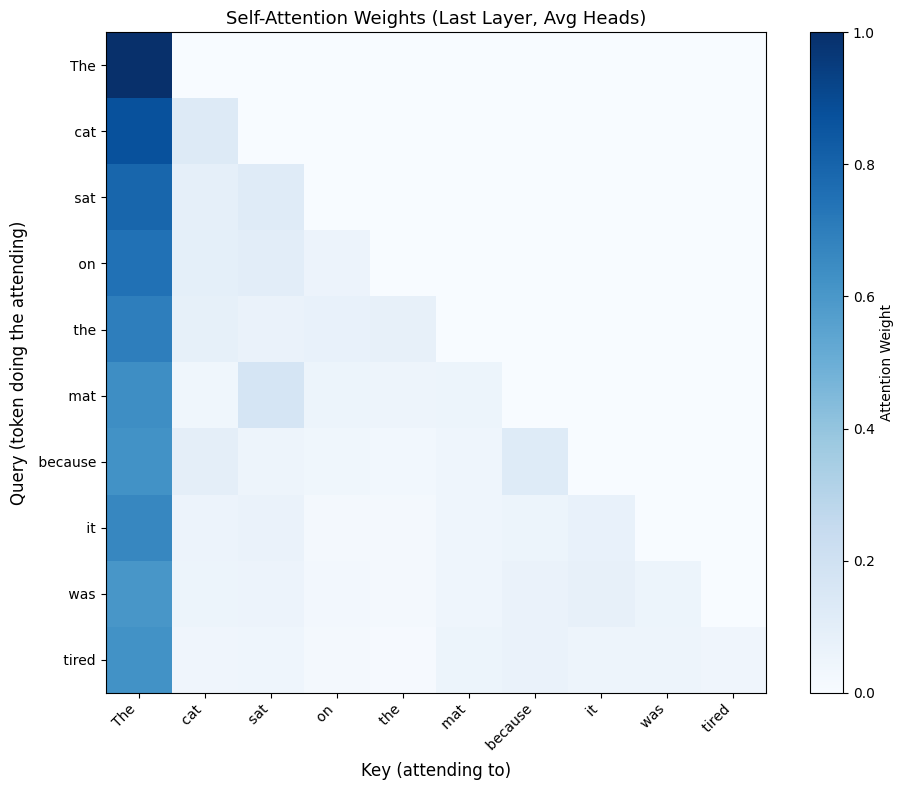


🔍 Look for: which token does "it" attend to most? (should be "cat"!)


In [20]:
prompt = "The cat sat on the mat because it was tired"
input_ids = gpt2_tokenizer.encode(prompt, return_tensors="pt")
tokens = [gpt2_tokenizer.decode([t]) for t in input_ids[0]]

with torch.no_grad():
    outputs = gpt2_model(input_ids, output_attentions=True)

# outputs.attentions is a tuple of (num_layers,) each with shape [batch, heads, seq, seq]
# Let's look at the last layer, averaged across heads
last_layer_attn = outputs.attentions[-1][0].mean(dim=0)  # [seq, seq]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(last_layer_attn.numpy(), cmap='Blues')
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(tokens, fontsize=10)
ax.set_xlabel('Key (attending to)', fontsize=12)
ax.set_ylabel('Query (token doing the attending)', fontsize=12)
plt.colorbar(im, label='Attention Weight')
ax.set_title('Self-Attention Weights (Last Layer, Avg Heads)', fontsize=13)
plt.tight_layout()
plt.show()

print('\n🔍 Look for: which token does "it" attend to most? (should be "cat"!)')

### 3.4 — Autoregressive Generation Step-by-Step

See the model predict one token at a time:

In [21]:
prompt = "Machine learning is"
input_ids = gpt2_tokenizer.encode(prompt, return_tensors="pt")
generated = input_ids.clone()

print(f"Starting: '{prompt}'\n")
print(f"{'Step':<6} {'New Token':<15} {'Probability':>12}  {'Running Text'}")
print("-" * 80)

for step in range(15):
    with torch.no_grad():
        logits = gpt2_model(generated).logits[0, -1, :]
    probs = F.softmax(logits, dim=0)

    # Greedy: pick the highest probability token
    next_id = torch.argmax(probs).unsqueeze(0).unsqueeze(0)
    prob = probs[next_id[0, 0]].item()
    token_str = gpt2_tokenizer.decode(next_id[0])

    generated = torch.cat([generated, next_id], dim=1)
    full_text = gpt2_tokenizer.decode(generated[0])

    print(f"{step+1:<6} '{token_str:<13}' {prob:>12.4f}  {full_text}")

Starting: 'Machine learning is'

Step   New Token        Probability  Running Text
--------------------------------------------------------------------------------
1      ' a           '       0.1383  Machine learning is a
2      ' very        '       0.0512  Machine learning is a very
3      ' powerful    '       0.0764  Machine learning is a very powerful
4      ' tool        '       0.2763  Machine learning is a very powerful tool
5      ' for         '       0.1947  Machine learning is a very powerful tool for
6      ' learning    '       0.0404  Machine learning is a very powerful tool for learning
7      ' about       '       0.1659  Machine learning is a very powerful tool for learning about
8      ' the         '       0.1651  Machine learning is a very powerful tool for learning about the
9      ' world       '       0.3604  Machine learning is a very powerful tool for learning about the world
10     ' around      '       0.4991  Machine learning is a very powerful tool for le

**💡 Key Takeaway:** Each token is generated one at a time, feeding back as input for the next prediction. This is **autoregressive decoding**. GPT-4 does this ~100K times per second.

---

# 04 — Dialogue State Management

> *"How Claude tracks that ‘it’ refers to your earlier question — managing context across turns"*

### 4.1 — Building a Slot-Filling Dialogue State Tracker

In [22]:
import re
from dataclasses import dataclass, field
from typing import Optional, List

@dataclass
class DialogueState:
    """Tracks the state of a flight booking conversation."""
    intent: Optional[str] = None
    destination: Optional[str] = None
    date: Optional[str] = None
    passengers: Optional[int] = None
    travel_class: str = "economy"  # default
    return_date: Optional[str] = None
    history: List[dict] = field(default_factory=list)
    actions_taken: List[str] = field(default_factory=list)

    @property
    def required_slots(self):
        return {"destination": self.destination, "date": self.date, "passengers": self.passengers}

    @property
    def missing_slots(self):
        return [k for k, v in self.required_slots.items() if v is None]

    @property
    def all_required_filled(self):
        return len(self.missing_slots) == 0

    def display(self):
        print("\n┌─ Dialogue State ─────────────────────────┐")
        print(f"│  Intent:       {self.intent or 'UNKNOWN':>20} │")
        print(f"│  Destination:  {(self.destination or 'MISSING ❌'):>20} │")
        print(f"│  Date:         {(self.date or 'MISSING ❌'):>20} │")
        print(f"│  Passengers:   {(str(self.passengers) if self.passengers else 'MISSING ❌'):>20} │")
        print(f"│  Class:        {self.travel_class:>20} │")
        print(f"│  Return Date:  {(self.return_date or 'not set'):>20} │")
        print(f"└───────────────────────────────────────────┘")

print("DialogueState class defined.")
print("See next cell for the entity extraction engine.")

DialogueState class defined.
See next cell for the entity extraction engine.


In [23]:
# Simple rule-based entity extraction (in production, an LLM does this)
CITIES = ["paris", "london", "tokyo", "new york", "delhi", "mumbai", "berlin", "rome", "sydney"]

def extract_entities(message: str, state: DialogueState) -> DialogueState:
    """Parse a user message and update the dialogue state."""
    msg = message.lower()

    # Intent detection
    if any(w in msg for w in ["book", "fly", "flight", "travel"]):
        state.intent = "book_flight"
    elif any(w in msg for w in ["cancel", "refund"]):
        state.intent = "cancel_booking"

    # Destination extraction
    for city in CITIES:
        if city in msg:
            state.destination = city.title()

    # Date extraction (simple patterns)
    date_patterns = [
        r'(next (?:monday|tuesday|wednesday|thursday|friday|saturday|sunday))',
        r'(tomorrow)',
        r'(\d{1,2}[/-]\d{1,2}[/-]\d{2,4})',
        r'((?:jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)\w* \d{1,2})',
    ]
    for pattern in date_patterns:
        match = re.search(pattern, msg)
        if match:
            state.date = match.group(1)

    # Passenger count
    pax_match = re.search(r'(\d+)\s*(?:passenger|people|person|ticket|seat)', msg)
    if pax_match:
        state.passengers = int(pax_match.group(1))
    elif "just me" in msg or "solo" in msg:
        state.passengers = 1

    # Travel class
    if "business" in msg:
        state.travel_class = "business"
    elif "first class" in msg:
        state.travel_class = "first"

    # Log to history
    state.history.append({"role": "user", "content": message})
    return state


def get_next_question(state: DialogueState) -> str:
    """Determine what to ask next based on missing slots."""
    if state.intent is None:
        return "How can I help you today?"
    if state.destination is None:
        return "Where would you like to fly to?"
    if state.date is None:
        return "When would you like to travel?"
    if state.passengers is None:
        return "How many passengers?"
    return None  # All slots filled!

print("Entity extraction and question logic defined.")

Entity extraction and question logic defined.


In [24]:
# Simulate a multi-turn conversation
state = DialogueState()

conversation = [
    "I want to book a flight to Paris",
    "Next Friday please",
    "2 passengers, business class",
]

print("✈️  Flight Booking Chatbot Simulation")
print("=" * 50)

for turn_num, user_msg in enumerate(conversation, 1):
    print(f"\n--- Turn {turn_num} ---")
    print(f"🗣️  User: \"{user_msg}\"")

    state = extract_entities(user_msg, state)
    state.display()

    next_q = get_next_question(state)
    if next_q:
        print(f"\n🤖 Bot: {next_q}")
        state.history.append({"role": "assistant", "content": next_q})
    else:
        print(f"\n✅ All slots filled! Ready to search flights.")
        print(f"   Searching: {state.destination}, {state.date}, "
              f"{state.passengers} pax, {state.travel_class} class")

✈️  Flight Booking Chatbot Simulation

--- Turn 1 ---
🗣️  User: "I want to book a flight to Paris"

┌─ Dialogue State ─────────────────────────┐
│  Intent:                book_flight │
│  Destination:                 Paris │
│  Date:                    MISSING ❌ │
│  Passengers:              MISSING ❌ │
│  Class:                     economy │
│  Return Date:               not set │
└───────────────────────────────────────────┘

🤖 Bot: When would you like to travel?

--- Turn 2 ---
🗣️  User: "Next Friday please"

┌─ Dialogue State ─────────────────────────┐
│  Intent:                book_flight │
│  Destination:                 Paris │
│  Date:                  next friday │
│  Passengers:              MISSING ❌ │
│  Class:                     economy │
│  Return Date:               not set │
└───────────────────────────────────────────┘

🤖 Bot: How many passengers?

--- Turn 3 ---
🗣️  User: "2 passengers, business class"

┌─ Dialogue State ─────────────────────────┐
│  Intent:         

### 4.2 — The Context Window as State (LLM-Style)

In modern LLM chatbots, the full prompt IS the state. Here’s what ChatGPT/Claude actually sees:

In [25]:
def build_llm_prompt(state: DialogueState) -> str:
    """Build the full prompt that an LLM would see — the context window IS the state."""
    prompt_parts = []

    # System prompt
    prompt_parts.append(
        "[System] You are TravelBot, a helpful flight booking assistant.\n"
        "Rules: Always confirm before booking. Never make up flight numbers.\n"
        "Tools: search_flights(dest, date, pax), book_flight(flight_id)\n"
    )

    # Conversation history (this IS the dialogue state for LLMs)
    for turn in state.history:
        role = turn['role'].capitalize()
        prompt_parts.append(f"[{role}] {turn['content']}")

    return "\n".join(prompt_parts)

# Show what the LLM actually sees
print("📝 What the LLM sees as its 'state' (the full prompt):")
print("=" * 60)
print(build_llm_prompt(state))
print("=" * 60)
print(f"\nTotal tokens (approx): {len(enc.encode(build_llm_prompt(state)))}")
print(f"GPT-4 context limit:   128,000 tokens")
print(f"Claude context limit:  200,000 tokens")

📝 What the LLM sees as its 'state' (the full prompt):
[System] You are TravelBot, a helpful flight booking assistant.
Rules: Always confirm before booking. Never make up flight numbers.
Tools: search_flights(dest, date, pax), book_flight(flight_id)

[User] I want to book a flight to Paris
[Assistant] When would you like to travel?
[User] Next Friday please
[Assistant] How many passengers?
[User] 2 passengers, business class

Total tokens (approx): 89
GPT-4 context limit:   128,000 tokens
Claude context limit:  200,000 tokens


---

# 05 — Response Generation

> *"Prompt engineering, RAG, and function calling — how the system crafts useful replies"*

### 5.1 — Prompt Engineering: System Prompts Shape Behaviour

In [26]:
def build_system_prompt(persona, rules, tools=None, examples=None):
    """Construct a structured system prompt — the key to controlling LLM behaviour."""
    prompt = f"""You are {persona}.

RULES:
"""
    for rule in rules:
        prompt += f"- {rule}\n"

    if tools:
        prompt += "\nTOOLS AVAILABLE:\n"
        for tool_name, tool_desc in tools.items():
            prompt += f"- {tool_name}: {tool_desc}\n"

    if examples:
        prompt += "\nEXAMPLES:\n"
        for user_q, bot_a in examples:
            prompt += f"User: {user_q}\nAssistant: {bot_a}\n\n"

    return prompt

# Build a TravelBot system prompt (like slide 21)
system_prompt = build_system_prompt(
    persona="TravelBot, a friendly and concise travel assistant",
    rules=[
        "Always be polite and concise",
        "If unsure, say 'I'm not sure' — never fabricate information",
        "Never make up flight numbers or prices",
        "Use bullet points for listing options",
        "Always confirm details before booking",
    ],
    tools={
        "search_flights(dest, date, pax)": "Search available flights",
        "book_flight(flight_id)": "Book a specific flight",
        "get_weather(city, date)": "Get weather forecast",
    },
    examples=[
        ("What's the weather in Paris?",
         "Let me check that for you. [calls get_weather('Paris', 'today')]\nParis is 14°C with partly cloudy skies."),
    ]
)

print(system_prompt)

You are TravelBot, a friendly and concise travel assistant.

RULES:
- Always be polite and concise
- If unsure, say 'I'm not sure' — never fabricate information
- Never make up flight numbers or prices
- Use bullet points for listing options
- Always confirm details before booking

TOOLS AVAILABLE:
- search_flights(dest, date, pax): Search available flights
- book_flight(flight_id): Book a specific flight
- get_weather(city, date): Get weather forecast

EXAMPLES:
User: What's the weather in Paris?
Assistant: Let me check that for you. [calls get_weather('Paris', 'today')]
Paris is 14°C with partly cloudy skies.




### 5.2 — RAG: Retrieval-Augmented Generation

Build a mini RAG pipeline from scratch: **Retrieve → Augment → Generate**

In [27]:
# --- STEP 1: Build a simple vector knowledge base ---

knowledge_base = [
    "Flight AF123 from Delhi to Paris departs at 10:30 AM and costs ₹45,000. Duration: 9h 15m.",
    "Flight BA456 from Delhi to London departs at 2:15 PM and costs ₹52,000. Duration: 10h 30m.",
    "Flight EK789 from Mumbai to Dubai departs at 6:00 AM and costs ₹25,000. Duration: 3h 45m.",
    "Paris weather in March: average 8-14°C, partly cloudy, occasional rain. Pack layers.",
    "London weather in March: average 5-12°C, rainy. Bring an umbrella and warm jacket.",
    "Dubai weather in March: average 20-30°C, sunny and warm. Light clothing recommended.",
    "Visa for France (Indian citizens): Schengen visa required. Processing: 15 working days.",
    "Visa for UK (Indian citizens): Standard visitor visa required. Processing: 3 weeks.",
    "Visa for UAE (Indian citizens): Visa on arrival for 14 days, or e-visa for 30/90 days.",
]

# Embed the knowledge base
kb_embeddings = model.encode(knowledge_base)
print(f"Knowledge base: {len(knowledge_base)} documents, {kb_embeddings.shape[1]}-dim embeddings")

Knowledge base: 9 documents, 384-dim embeddings


In [28]:
# --- STEP 2: Retrieval function ---

def retrieve(query, top_k=3):
    """Retrieve the top-k most relevant documents for a query."""
    query_vec = model.encode([query])
    sims = cosine_similarity(query_vec, kb_embeddings)[0]
    top_indices = sims.argsort()[-top_k:][::-1]
    results = [(knowledge_base[i], sims[i]) for i in top_indices]
    return results

# --- STEP 3: Augment the prompt ---

def build_rag_prompt(user_query, retrieved_docs):
    """Augment the prompt with retrieved context."""
    context = "\n".join([f"- {doc}" for doc, _ in retrieved_docs])
    return f"""You are a helpful travel assistant. Answer the user's question using ONLY the
information provided in the CONTEXT below. If the context doesn't contain the answer,
say "I don't have that information."

CONTEXT:
{context}

USER QUESTION: {user_query}

ANSWER:"""

# --- Full RAG pipeline demo ---

queries = [
    "What flights go to Paris from Delhi?",
    "Do I need a visa for Dubai?",
    "What should I wear in London in March?",
]

for query in queries:
    print(f"\n{'='*70}")
    print(f"🗣️  User: \"{query}\"\n")

    # Retrieve
    docs = retrieve(query, top_k=2)
    print(f"🔍 Retrieved ({len(docs)} docs):")
    for doc, sim in docs:
        print(f"   [{sim:.3f}] {doc}")

    # Augment
    rag_prompt = build_rag_prompt(query, docs)
    print(f"\n📝 Augmented prompt ({len(enc.encode(rag_prompt))} tokens)")
    print(f"   (In production, this entire prompt is sent to GPT-4/Claude for generation)")


🗣️  User: "What flights go to Paris from Delhi?"

🔍 Retrieved (2 docs):
   [0.700] Flight AF123 from Delhi to Paris departs at 10:30 AM and costs ₹45,000. Duration: 9h 15m.
   [0.536] Flight BA456 from Delhi to London departs at 2:15 PM and costs ₹52,000. Duration: 10h 30m.

📝 Augmented prompt (121 tokens)
   (In production, this entire prompt is sent to GPT-4/Claude for generation)

🗣️  User: "Do I need a visa for Dubai?"

🔍 Retrieved (2 docs):
   [0.698] Visa for UAE (Indian citizens): Visa on arrival for 14 days, or e-visa for 30/90 days.
   [0.440] Flight EK789 from Mumbai to Dubai departs at 6:00 AM and costs ₹25,000. Duration: 3h 45m.

📝 Augmented prompt (117 tokens)
   (In production, this entire prompt is sent to GPT-4/Claude for generation)

🗣️  User: "What should I wear in London in March?"

🔍 Retrieved (2 docs):
   [0.602] London weather in March: average 5-12°C, rainy. Bring an umbrella and warm jacket.
   [0.414] Dubai weather in March: average 20-30°C, sunny and warm. Li

### 5.3 — Function Calling / Tool Use

Simulating how LLMs decide to call tools:

In [29]:
import json

# Define available tools (as would be passed to GPT-4 / Claude)
tools = {
    "search_flights": {
        "description": "Search for available flights",
        "parameters": {"dest": "string", "date": "string", "pax": "integer"},
        "execute": lambda dest, date, pax: {
            "flights": [
                {"id": "AF123", "airline": "Air France", "price": "₹45,000", "departs": "10:30"},
                {"id": "LH456", "airline": "Lufthansa", "price": "₹48,000", "departs": "14:15"},
            ]
        }
    },
    "get_weather": {
        "description": "Get weather forecast for a city",
        "parameters": {"city": "string", "date": "string"},
        "execute": lambda city, date: {
            "temp": "14°C", "condition": "partly cloudy", "rain_chance": "20%"
        }
    },
    "book_flight": {
        "description": "Book a specific flight",
        "parameters": {"flight_id": "string"},
        "execute": lambda flight_id: {
            "status": "confirmed", "booking_ref": "TRV-2026-78934"
        }
    }
}

# Simulate the LLM deciding to call a tool
def simulate_tool_call(user_query):
    """Simulate the full tool-use pipeline (in reality, the LLM generates the JSON)."""
    print(f"\n🗣️  User: \"{user_query}\"")

    # Simulated LLM decisions (in production, GPT-4/Claude generates this)
    if "weather" in user_query.lower():
        tool_call = {"function": "get_weather", "args": {"city": "Paris", "date": "2026-03-13"}}
    elif "flight" in user_query.lower() or "fly" in user_query.lower():
        tool_call = {"function": "search_flights", "args": {"dest": "Paris", "date": "2026-03-13", "pax": 1}}
    elif "book" in user_query.lower():
        tool_call = {"function": "book_flight", "args": {"flight_id": "AF123"}}
    else:
        print("\n🤖 LLM: (no tool needed, responding directly)")
        return

    print(f"\n🤖 LLM decides to call tool:")
    print(f"   {json.dumps(tool_call, indent=2)}")

    # Execute the tool
    tool = tools[tool_call["function"]]
    result = tool["execute"](**tool_call["args"])
    print(f"\n🔧 Tool result:")
    print(f"   {json.dumps(result, indent=2)}")

    print(f"\n🤖 LLM weaves result into natural language response.")

# Demo
simulate_tool_call("What's the weather in Paris next Friday?")
simulate_tool_call("Find flights to Paris")
simulate_tool_call("Book the Air France flight")


🗣️  User: "What's the weather in Paris next Friday?"

🤖 LLM decides to call tool:
   {
  "function": "get_weather",
  "args": {
    "city": "Paris",
    "date": "2026-03-13"
  }
}

🔧 Tool result:
   {
  "temp": "14\u00b0C",
  "condition": "partly cloudy",
  "rain_chance": "20%"
}

🤖 LLM weaves result into natural language response.

🗣️  User: "Find flights to Paris"

🤖 LLM decides to call tool:
   {
  "function": "search_flights",
  "args": {
    "dest": "Paris",
    "date": "2026-03-13",
    "pax": 1
  }
}

🔧 Tool result:
   {
  "flights": [
    {
      "id": "AF123",
      "airline": "Air France",
      "price": "\u20b945,000",
      "departs": "10:30"
    },
    {
      "id": "LH456",
      "airline": "Lufthansa",
      "price": "\u20b948,000",
      "departs": "14:15"
    }
  ]
}

🤖 LLM weaves result into natural language response.

🗣️  User: "Book the Air France flight"

🤖 LLM decides to call tool:
   {
  "function": "search_flights",
  "args": {
    "dest": "Paris",
    "date": 

---

# 06 — Memory

> *"Why Gemini can remember your preferences across sessions"*

### 6.1 — Conversation Buffer Memory

In [30]:
class BufferMemory:
    """Stores the full conversation history (simplest memory type)."""

    def __init__(self, max_turns=None):
        self.history = []
        self.max_turns = max_turns  # None = unlimited

    def add(self, role, content):
        self.history.append({"role": role, "content": content})
        if self.max_turns and len(self.history) > self.max_turns * 2:
            self.history = self.history[-self.max_turns * 2:]  # sliding window

    def get_context(self):
        return "\n".join([f"[{t['role']}] {t['content']}" for t in self.history])

    def token_count(self):
        return len(enc.encode(self.get_context()))

# Simulate a multi-turn conversation
buffer = BufferMemory()

turns = [
    ("user", "I want to plan a trip to Tokyo."),
    ("assistant", "Great choice! When are you planning to visit?"),
    ("user", "Sometime in April. I love cherry blossoms."),
    ("assistant", "April is perfect for cherry blossoms! The peak bloom is usually late March to mid-April."),
    ("user", "What about hotels near Shinjuku?"),
    ("assistant", "Here are 3 hotels near Shinjuku station..."),
    ("user", "I prefer the second one. Also, I'm vegetarian."),
    ("assistant", "Noted! The Park Hyatt it is. I'll find vegetarian-friendly restaurants nearby."),
]

print("💬 Conversation Buffer Memory Demo\n")
for role, content in turns:
    buffer.add(role, content)

print(buffer.get_context())
print(f"\n📊 Token usage: {buffer.token_count()} tokens")
print(f"   GPT-4 limit: 128,000 | Claude limit: 200,000")

💬 Conversation Buffer Memory Demo

[user] I want to plan a trip to Tokyo.
[assistant] Great choice! When are you planning to visit?
[user] Sometime in April. I love cherry blossoms.
[assistant] April is perfect for cherry blossoms! The peak bloom is usually late March to mid-April.
[user] What about hotels near Shinjuku?
[assistant] Here are 3 hotels near Shinjuku station...
[user] I prefer the second one. Also, I'm vegetarian.
[assistant] Noted! The Park Hyatt it is. I'll find vegetarian-friendly restaurants nearby.

📊 Token usage: 119 tokens
   GPT-4 limit: 128,000 | Claude limit: 200,000


### 6.2 — Summary Memory

In [31]:
class SummaryMemory:
    """Compresses older turns into a summary, keeps recent turns verbatim."""

    def __init__(self, recent_turns=4):
        self.summary = ""
        self.recent = []
        self.recent_turns = recent_turns

    def add(self, role, content):
        self.recent.append({"role": role, "content": content})
        if len(self.recent) > self.recent_turns * 2:
            # Summarise the oldest turns (in production, an LLM does this)
            old_turns = self.recent[:2]  # Remove oldest pair
            self.recent = self.recent[2:]
            old_text = " | ".join([f"{t['role']}: {t['content']}" for t in old_turns])
            # Simulated summarisation
            self.summary += f" [{old_text[:80]}...]"

    def get_context(self):
        parts = []
        if self.summary:
            parts.append(f"[Summary of earlier conversation: {self.summary.strip()}]\n")
        parts.append("\n".join([f"[{t['role']}] {t['content']}" for t in self.recent]))
        return "\n".join(parts)

# Demo
summary_mem = SummaryMemory(recent_turns=3)
for role, content in turns:
    summary_mem.add(role, content)

print("🗑️ Summary Memory Demo\n")
print(summary_mem.get_context())
print(f"\n📊 Token usage: {len(enc.encode(summary_mem.get_context()))} tokens")
print(f"   vs Buffer: {buffer.token_count()} tokens")
print(f"   Savings: {buffer.token_count() - len(enc.encode(summary_mem.get_context()))} tokens")

🗑️ Summary Memory Demo

[Summary of earlier conversation: [user: I want to plan a trip to Tokyo. | assistant: Great choice! When are you pl...]]

[user] Sometime in April. I love cherry blossoms.
[assistant] April is perfect for cherry blossoms! The peak bloom is usually late March to mid-April.
[user] What about hotels near Shinjuku?
[assistant] Here are 3 hotels near Shinjuku station...
[user] I prefer the second one. Also, I'm vegetarian.
[assistant] Noted! The Park Hyatt it is. I'll find vegetarian-friendly restaurants nearby.

📊 Token usage: 125 tokens
   vs Buffer: 119 tokens
   Savings: -6 tokens


### 6.3 — Entity / Fact Store Memory

In [32]:
class EntityMemory:
    """Extracts and stores structured facts about the user."""

    def __init__(self):
        self.facts = {}  # key-value store

    def extract_and_store(self, message):
        """Simple rule-based extraction (LLMs do this in production)."""
        msg = message.lower()

        # Preference extraction
        if "vegetarian" in msg:
            self.facts["diet"] = "vegetarian"
        if "vegan" in msg:
            self.facts["diet"] = "vegan"
        if "window seat" in msg:
            self.facts["seat_preference"] = "window"
        if "aisle" in msg:
            self.facts["seat_preference"] = "aisle"
        if "cherry blossom" in msg:
            self.facts["interests"] = self.facts.get("interests", []) + ["cherry blossoms"]

        # Destination extraction
        for city in ["tokyo", "paris", "london", "dubai"]:
            if city in msg:
                self.facts["destination"] = city.title()

    def get_context(self):
        if not self.facts:
            return "No user facts stored yet."
        lines = ["[Known facts about this user]"]
        for key, value in self.facts.items():
            lines.append(f"  - {key}: {value}")
        return "\n".join(lines)

# Demo
entity_mem = EntityMemory()
for role, content in turns:
    if role == "user":
        entity_mem.extract_and_store(content)

print("🗃️ Entity Memory Demo\n")
print(entity_mem.get_context())
print(f"\n📊 Token usage: {len(enc.encode(entity_mem.get_context()))} tokens")
print(f"   vs Buffer: {buffer.token_count()} tokens  (massive savings!)")

🗃️ Entity Memory Demo

[Known facts about this user]
  - destination: Tokyo
  - interests: ['cherry blossoms']
  - diet: vegetarian

📊 Token usage: 28 tokens
   vs Buffer: 119 tokens  (massive savings!)


### 6.4 — Vector / Semantic Memory

In [33]:
class VectorMemory:
    """Stores conversation chunks as embeddings for semantic retrieval."""

    def __init__(self, embed_model):
        self.model = embed_model
        self.memories = []       # raw text
        self.embeddings = None   # numpy array

    def store(self, text):
        self.memories.append(text)
        self.embeddings = self.model.encode(self.memories)

    def retrieve(self, query, top_k=2):
        if not self.memories:
            return []
        query_vec = self.model.encode([query])
        sims = cosine_similarity(query_vec, self.embeddings)[0]
        top_idx = sims.argsort()[-top_k:][::-1]
        return [(self.memories[i], sims[i]) for i in top_idx]

# Store conversation turns as memories
vec_mem = VectorMemory(model)

# Simulate memories from PAST sessions (this is cross-session memory)
past_memories = [
    "User prefers vegetarian food and usually travels solo.",
    "User visited Paris in January 2025 and stayed at Hotel Le Marais.",
    "User loves cherry blossoms and wants to visit Japan in spring.",
    "User prefers window seats and usually flies economy.",
    "User is allergic to peanuts — always flag this for restaurant recommendations.",
    "User's budget is typically ₹50,000-80,000 for international flights.",
]

for mem in past_memories:
    vec_mem.store(mem)

# Now retrieve relevant memories for a new query
queries = [
    "I'm planning a trip — what do I usually prefer?",
    "Any food allergies to be aware of?",
    "What's my budget for flights?",
]

print("🧠 Vector Memory Demo — Cross-Session Retrieval\n")
for q in queries:
    results = vec_mem.retrieve(q, top_k=2)
    print(f"🗣️  Query: \"{q}\"")
    for mem, sim in results:
        print(f"   [{sim:.3f}] {mem}")
    print()

🧠 Vector Memory Demo — Cross-Session Retrieval

🗣️  Query: "I'm planning a trip — what do I usually prefer?"
   [0.341] User prefers vegetarian food and usually travels solo.
   [0.276] User's budget is typically ₹50,000-80,000 for international flights.

🗣️  Query: "Any food allergies to be aware of?"
   [0.475] User is allergic to peanuts — always flag this for restaurant recommendations.
   [0.182] User prefers vegetarian food and usually travels solo.

🗣️  Query: "What's my budget for flights?"
   [0.742] User's budget is typically ₹50,000-80,000 for international flights.
   [0.258] User prefers window seats and usually flies economy.



### 6.5 — Hybrid / Tiered Memory (Putting It All Together)

In [34]:
class HybridMemory:
    """
    Combines all memory types into a tiered system:
      - Working memory   = current turn context
      - Short-term       = buffer of recent turns
      - Long-term        = vector store + entity facts
    """

    def __init__(self, embed_model):
        self.buffer = BufferMemory(max_turns=5)       # short-term
        self.entities = EntityMemory()                  # long-term facts
        self.vectors = VectorMemory(embed_model)        # long-term semantic

    def process_turn(self, role, content):
        """Process a new conversation turn across all memory tiers."""
        # Short-term: add to buffer
        self.buffer.add(role, content)

        if role == "user":
            # Long-term: extract entities
            self.entities.extract_and_store(content)
            # Long-term: store as vector memory
            self.vectors.store(f"{role}: {content}")

    def build_context(self, current_query):
        """Build the full context for the LLM using all memory tiers."""
        parts = []

        # Tier 3: Long-term entity facts
        entity_ctx = self.entities.get_context()
        if "No user facts" not in entity_ctx:
            parts.append(f"=== LONG-TERM MEMORY (Entity Facts) ===\n{entity_ctx}")

        # Tier 3: Long-term vector retrieval
        relevant = self.vectors.retrieve(current_query, top_k=2)
        if relevant:
            vec_ctx = "\n".join([f"  - {mem} (relevance: {sim:.2f})" for mem, sim in relevant])
            parts.append(f"=== LONG-TERM MEMORY (Relevant Past Context) ===\n{vec_ctx}")

        # Tier 2: Short-term buffer
        parts.append(f"=== SHORT-TERM MEMORY (Recent Turns) ===\n{self.buffer.get_context()}")

        # Tier 1: Working memory (current query)
        parts.append(f"=== CURRENT QUERY ===\n{current_query}")

        return "\n\n".join(parts)

# Demo
hybrid = HybridMemory(model)

# Load past memories
for mem in past_memories:
    hybrid.vectors.store(mem)

# Simulate current session
for role, content in turns:
    hybrid.process_turn(role, content)

# Build context for a new query
new_query = "Book my usual kind of flight to Tokyo"
context = hybrid.build_context(new_query)

print("🧠 Hybrid Memory — Full Context for LLM\n")
print(context)
print(f"\n📊 Total tokens: {len(enc.encode(context))}")

🧠 Hybrid Memory — Full Context for LLM

=== LONG-TERM MEMORY (Entity Facts) ===
[Known facts about this user]
  - destination: Tokyo
  - interests: ['cherry blossoms']
  - diet: vegetarian

=== LONG-TERM MEMORY (Relevant Past Context) ===
  - user: I want to plan a trip to Tokyo. (relevance: 0.77)
  - User's budget is typically ₹50,000-80,000 for international flights. (relevance: 0.40)

=== SHORT-TERM MEMORY (Recent Turns) ===
[user] I want to plan a trip to Tokyo.
[assistant] Great choice! When are you planning to visit?
[user] Sometime in April. I love cherry blossoms.
[assistant] April is perfect for cherry blossoms! The peak bloom is usually late March to mid-April.
[user] What about hotels near Shinjuku?
[assistant] Here are 3 hotels near Shinjuku station...
[user] I prefer the second one. Also, I'm vegetarian.
[assistant] Noted! The Park Hyatt it is. I'll find vegetarian-friendly restaurants nearby.

=== CURRENT QUERY ===
Book my usual kind of flight to Tokyo

📊 Total tokens: 24

---

# 🏁 Putting It All Together

The complete pipeline that runs when you type a message into ChatGPT:

In [35]:
def full_pipeline_demo(user_message):
    """
    Demonstrate the complete GenAI chatbot pipeline end-to-end.
    """
    print(f"\n{'='*70}")
    print(f"  🗣️  USER: \"{user_message}\"")
    print(f"{'='*70}")

    # Step 1: TOKENISE
    tokens = enc.encode(user_message)
    token_strs = [enc.decode([t]) for t in tokens]
    print(f"\n➀ TOKENISE  →  {len(tokens)} tokens")
    print(f"   {token_strs}")

    # Step 2: EMBED
    embedding = model.encode([user_message])
    print(f"\n➁ EMBED     →  {embedding.shape[1]}-dimensional vector")
    print(f"   [{embedding[0][0]:.4f}, {embedding[0][1]:.4f}, {embedding[0][2]:.4f}, ... ]")

    # Step 3: RETRIEVE (RAG)
    relevant_docs = retrieve(user_message, top_k=2)
    print(f"\n➂ RETRIEVE  →  {len(relevant_docs)} relevant docs from knowledge base")
    for doc, sim in relevant_docs:
        print(f"   [{sim:.3f}] {doc[:70]}...")

    # Step 4: INFER (simulated — we'd need GPT-4 API for real inference)
    print(f"\n➃ INFER     →  Transformer forward pass (simulated)")
    print(f"   → {gpt2_model.config.n_layer} layers, {gpt2_model.config.n_head} attention heads")
    print(f"   → Generates logits over {gpt2_model.config.vocab_size:,} token vocabulary")

    # Step 5: TRACK STATE
    temp_state = DialogueState()
    temp_state = extract_entities(user_message, temp_state)
    print(f"\n➄ STATE     →  intent={temp_state.intent}, dest={temp_state.destination}, date={temp_state.date}")

    # Step 6: GENERATE
    input_ids = gpt2_tokenizer.encode(user_message, return_tensors="pt")
    with torch.no_grad():
        output = gpt2_model.generate(input_ids, max_new_tokens=30,
                                      pad_token_id=gpt2_tokenizer.eos_token_id,
                                      temperature=0.7, do_sample=True)
    response = gpt2_tokenizer.decode(output[0], skip_special_tokens=True)
    print(f"\n➅ GENERATE  →  (GPT-2 completion, for illustration)")
    print(f"   \"{response[:120]}...\"")

    # Step 7: REMEMBER
    print(f"\n➆ REMEMBER  →  Stored to buffer + entity memory + vector store")
    print(f"{'='*70}\n")

# Run the full pipeline
full_pipeline_demo("Book me a flight to Paris next Friday")
full_pipeline_demo("What is machine learning?")


  🗣️  USER: "Book me a flight to Paris next Friday"

➀ TOKENISE  →  8 tokens
   ['Book', ' me', ' a', ' flight', ' to', ' Paris', ' next', ' Friday']

➁ EMBED     →  384-dimensional vector
   [0.1119, -0.0201, 0.0093, ... ]

➂ RETRIEVE  →  2 relevant docs from knowledge base
   [0.524] Flight AF123 from Delhi to Paris departs at 10:30 AM and costs ₹45,000...
   [0.378] Paris weather in March: average 8-14°C, partly cloudy, occasional rain...

➃ INFER     →  Transformer forward pass (simulated)
   → 12 layers, 12 attention heads
   → Generates logits over 50,257 token vocabulary

➄ STATE     →  intent=book_flight, dest=Paris, date=next friday

➅ GENERATE  →  (GPT-2 completion, for illustration)
   "Book me a flight to Paris next Friday!

I'm sure the airport is a better place to be than I thought. But I'm not sure th..."

➆ REMEMBER  →  Stored to buffer + entity memory + vector store


  🗣️  USER: "What is machine learning?"

➀ TOKENISE  →  5 tokens
   ['What', ' is', ' machine', ' lea

---

# 📝 Key Takeaways

| Building Block | What We Coded | Key Insight |
|---|---|---|
| **Tokenisation** | BPE, WordPiece, SentencePiece | Different tokenisers = different token counts = different costs |
| **Embeddings** | Similarity, analogies, t-SNE | Meaning becomes geometry — similar concepts cluster together |
| **Inference** | Forward pass, decoding, attention | Temperature and top-p control creativity vs coherence |
| **Dialogue State** | Slot filling, context window | LLMs use the full prompt as state; traditional bots use explicit slots |
| **Response Gen** | RAG pipeline, tool use | Retrieval grounds the LLM; tools extend its capabilities |
| **Memory** | Buffer, summary, entity, vector | Tiered memory enables cross-session personalisation |

**Next Class:** Attention Mechanisms, Transformer Architecture Deep-Dive, and Fine-tuning

---

# 🧪 Exercises

1. **Tokenisation:** Try tokenising the same Hindi sentence with all 3 tokenisers. Which is most efficient for Hindi?
2. **Embeddings:** Find 3 more word analogies that work (and one that doesn’t). Why do some fail?
3. **Decoding:** Generate 5 continuations of the same prompt with different temperatures. At what T does coherence break down?
4. **RAG:** Add 5 more documents to the knowledge base and test with new queries. How does retrieval quality change?
5. **Memory:** Implement a `WindowedSummaryMemory` that keeps the last 3 turns verbatim and summarises everything older.